# Forward addition and backward reduction factor sweep

This experiment measures how greedy-search batching affects blind performance,
known-signal recovery, selected feature counts, curve resolution, and runtime.
Both searches use `combined_rank(weight=0.75)`, separate feature sets and
parameters, no ensemble holdout, five members, three seeds, and post-search
knee selection. Forward selection is capped at 20 features.

In [1]:
import time
from pathlib import Path
import copy
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "mistic" / "svmSet.py").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svc, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

Matplotlib is building the font cache; this may take a moment.


## Fixed synthetic data and blind split

In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))

X_values, y_values = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=N_INFORMATIVE,
    n_redundant=N_REDUNDANT,
    n_repeated=0,
    n_classes=2,
    weights=[0.55, 0.45],
    class_sep=1.0,
    flip_y=0.03,
    shuffle=False,
    random_state=2026,
)
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="class")

MODEL_COUNTS = [5]
REFINEMENT_STEPS = [0, 10, 20, 50, 100]
SELECTION_STRATEGIES = ["forward_knee", "backward_knee"]
INNER_SEEDS = list(range(3))
BLIND_SET_SEED = 42
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
ENSEMBLE_VALIDATION_SIZE = 0.0
RANK_WEIGHT = 0.75
FORWARD_MAX_FEATURES = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]

X_train, X_blind, y_train, y_blind = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=BLIND_SET_SEED
)
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")

Training rows: 375; fixed blind rows: 125


## Search and evaluation helpers

In [3]:
def parameter_grid():
    return [
        paramSet(model={"C": cost}, kernel={"gamma": gamma})
        for cost in C_VALUES for gamma in GAMMA_VALUES
    ]


def metric_row(y_true, predictions, decision_values):
    return {
        "roc_auc": roc_auc_score(y_true, decision_values),
        "f1": f1_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "accuracy": accuracy_score(y_true, predictions),
    }


def ranked_unified_features(ensemble, limit=20):
    unified_set = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([
        feature for feature in ensemble.unified_sorted_features
        if feature in unified_set
    ], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    precision = signal_count / len(features) if len(features) else 0.0
    return signal_count / len(SIGNAL_FEATURES), precision


def fit_factor_ensemble(direction, factor, seed):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(
        X_scaled,
        np.asarray(y_train),
        num_feature_medoids=20,
        ensemble_validation_size=0.0,
        ensemble_validation_random_seed=50_000,
        ensemble_validation_stratify=True,
    )
    splits.classification(
        num_sets=5,
        validation_size=INNER_VALIDATION_SIZE,
        random_seed=seed,
    )
    ensemble = svmSet(
        SVC(kernel="precomputed", class_weight="balanced"),
        splits,
        score_method=score_svc(weight=1.0).score,
        kernel=kernelWrapper(type="rbf"),
        separate_feature_sets=True,
        separate_parameters=True,
    )
    options = dict(
        parameter_grid=parameter_grid(),
        feature_ranker=combined_rank(weight=0.75).compute,
        set_for_rank="sample",
        tune_models_each_step=False,
        post_find_knee=True,
    )
    if direction == "forward":
        ensemble.greedy_forward_selection(
            addition_factor=factor,
            max_features=20,
            **options,
        )
    else:
        ensemble.greedy_backward_selection(
            reduction_factor=factor,
            **options,
        )
    return scaler, ensemble


def result_row(ensemble, scaler, direction, factor, seed, elapsed):
    X_blind_scaled = scaler.transform(X_blind)
    predictions = ensemble.predict(X_blind_scaled)
    decisions = ensemble.decision_function(X_blind_scaled)
    top20 = ranked_unified_features(ensemble, 20)
    signal_recall, signal_precision = recovery(top20)
    member_predictions = np.column_stack([
        ensemble.predict(X_blind_scaled, model_index=i)
        for i in range(ensemble.num_models)
    ])
    disagreement = np.mean([
        np.mean(member_predictions[:, i] != member_predictions[:, j])
        for i in range(ensemble.num_models)
        for j in range(i + 1, ensemble.num_models)
    ])
    selected_counts = [len(features) for features in ensemble.features]
    return {
        "seed": seed,
        "direction": direction,
        "factor": factor,
        "rank_weight": 0.75,
        "num_models": ensemble.num_models,
        "mean_member_features": np.mean(selected_counts),
        "min_member_features": np.min(selected_counts),
        "max_member_features": np.max(selected_counts),
        "num_unified_features": len(ensemble.unified_features),
        "top20_signal_recall": signal_recall,
        "top20_signal_precision": signal_precision,
        "member_disagreement": disagreement,
        "search_curve_points": len(ensemble.feature_performance_),
        "elapsed_seconds": elapsed,
        **metric_row(y_blind, predictions, decisions),
    }


## Execute factor sweep

In [4]:
FACTORS = [0.0, 0.1, 0.25, 0.5]
DIRECTIONS = ["forward", "backward"]

rows = []
curve_rows = []
for direction in DIRECTIONS:
    for factor in FACTORS:
        for seed in INNER_SEEDS:
            started = time.perf_counter()
            scaler, ensemble = fit_factor_ensemble(direction, factor, seed)
            elapsed = time.perf_counter() - started
            rows.append(result_row(
                ensemble, scaler, direction, factor, seed, elapsed
            ))
            for step, performance in ensemble.feature_performance_.items():
                curve_rows.append({
                    "direction": direction,
                    "factor": factor,
                    "seed": seed,
                    "step": step,
                    "num_features": performance.num_features,
                    "cv_score": performance.score,
                })
            print(
                f"completed {direction}, factor={factor}, seed={seed}; "
                f"AUC={rows[-1]['roc_auc']:.4f}; "
                f"member features={rows[-1]['mean_member_features']:.1f}; "
                f"elapsed={elapsed:.1f}s"
            )

factor_results = pd.DataFrame(rows)
factor_curves = pd.DataFrame(curve_rows)
factor_results.to_csv(
    repo_root / "validation/Synthetic100_greedy_search_factor_sweep_results.csv",
    index=False,
)
factor_curves.to_csv(
    repo_root / "validation/Synthetic100_greedy_search_factor_sweep_curves.csv",
    index=False,
)
factor_results

Number of Features: 1, Score: 0.698


Number of Features: 2, Score: 0.751


Number of Features: 3, Score: 0.778


Number of Features: 4, Score: 0.767


Number of Features: 5, Score: 0.762


...

Number of Features: 25, Score: 0.839


Number of Features: 13, Score: 0.813
Number of Features: 7, Score: 0.771
Number of Features: 4, Score: 0.673


Number of Features: 2, Score: 0.646
Number of Features: 1, Score: 0.562


completed backward, factor=0.5, seed=2; AUC=0.8942; member features=13.0; elapsed=2.4s


,seed,direction,factor,rank_weight,num_models,mean_member_features,min_member_features,max_member_features,num_unified_features,top20_signal_recall,top20_signal_precision,member_disagreement,search_curve_points,elapsed_seconds,roc_auc,f1,balanced_accuracy,accuracy
0,0,forward,0.00,0.75,5,16.0,16,16,36,0.55,0.550000,0.1840,21,17.360125,0.950052,0.873950,0.884576,0.880
1,1,forward,0.00,0.75,5,12.0,12,12,24,0.65,0.650000,0.1360,21,19.467057,0.964803,0.882883,0.894022,0.896
2,2,forward,0.00,0.75,5,5.0,5,5,14,0.50,0.714286,0.1808,21,18.572069,0.934783,0.832000,0.841097,0.832
3,0,forward,0.10,0.75,5,10.0,10,10,23,0.60,0.600000,0.1568,5,5.672405,0.959110,0.867257,0.879529,0.880
4,1,forward,0.10,0.75,5,20.0,20,20,39,0.65,0.650000,0.1840,5,4.513829,0.956522,0.881356,0.891822,0.888
5,2,forward,0.10,0.75,5,10.0,10,10,25,0.65,0.650000,0.1824,5,4.555078,0.962733,0.892857,0.902950,0.904
6,0,forward,0.25,0.75,5,20.0,20,20,37,0.65,0.650000,0.1664,3,3.316738,0.953157,0.846154,0.863872,0.872
7,1,forward,0.25,0.75,5,20.0,20,20,35,0.65,0.650000,0.1392,3,3.212429,0.959369,0.904348,0.913561,0.912
8,2,forward,0.25,0.75,5,20.0,20,20,39,0.65,0.650000,0.1504,3,3.246591,0.954193,0.882883,0.894022,0.896
9,0,forward,0.50,0.75,5,20.0,20,20,37,0.65,0.650000,0.1664,3,3.301007,0.953157,0.846154,0.863872,0.872


## Aggregate comparison

In [5]:
factor_summary = factor_results.groupby(
    ["direction", "factor"]
).agg(
    mean_auc=("roc_auc", "mean"),
    sd_auc=("roc_auc", "std"),
    mean_f1=("f1", "mean"),
    mean_accuracy=("accuracy", "mean"),
    mean_balanced_accuracy=("balanced_accuracy", "mean"),
    mean_signal_recall=("top20_signal_recall", "mean"),
    mean_signal_precision=("top20_signal_precision", "mean"),
    mean_member_disagreement=("member_disagreement", "mean"),
    mean_member_features=("mean_member_features", "mean"),
    mean_unified_features=("num_unified_features", "mean"),
    mean_curve_points=("search_curve_points", "mean"),
    mean_elapsed_seconds=("elapsed_seconds", "mean"),
).reset_index()
factor_summary.round(4)

,direction,factor,mean_auc,sd_auc,mean_f1,mean_accuracy,mean_balanced_accuracy,mean_signal_recall,mean_signal_precision,mean_member_disagreement,mean_member_features,mean_unified_features,mean_curve_points,mean_elapsed_seconds
0,backward,0.00,0.9187,0.0043,0.8101,0.8240,0.8254,0.6000,0.6000,0.1813,11.3333,29.6667,100.0,44.8110
1,backward,0.10,0.9207,0.0058,0.8309,0.8427,0.8446,0.5500,0.5500,0.1749,11.0000,26.6667,36.0,9.0476
2,backward,0.25,0.9114,0.0208,0.8147,0.8320,0.8310,0.4500,0.4500,0.1888,15.3333,38.6667,17.0,4.0478
3,backward,0.50,0.9122,0.0217,0.8230,0.8347,0.8368,0.4500,0.4500,0.1749,17.0000,39.6667,8.0,2.2230
4,forward,0.00,0.9499,0.0150,0.8629,0.8693,0.8732,0.5667,0.6381,0.1669,11.0000,24.6667,21.0,18.4664
5,forward,0.10,0.9595,0.0031,0.8805,0.8907,0.8914,0.6333,0.6333,0.1744,13.3333,29.0000,5.0,4.9138
6,forward,0.25,0.9556,0.0033,0.8778,0.8933,0.8905,0.6500,0.6500,0.1520,20.0000,37.0000,3.0,3.2586
7,forward,0.50,0.9556,0.0033,0.8778,0.8933,0.8905,0.6500,0.6500,0.1520,20.0000,37.0000,3.0,3.2835


## Paired AUC changes relative to factor 0

In [6]:
auc_by_seed = factor_results.pivot_table(
    index=["direction", "seed"], columns="factor", values="roc_auc"
)
paired_auc_deltas = auc_by_seed.subtract(auc_by_seed[0.0], axis=0)
paired_auc_deltas.columns = [f"factor_{factor}_minus_0" for factor in paired_auc_deltas.columns]
paired_auc_deltas.round(4)

factor_0.0_minus_0  factor_0.1_minus_0  factor_0.25_minus_0  \
direction seed                                                                
backward  0                    0.0              0.0026               0.0080   
          1                    0.0              0.0101               0.0021   
          2                    0.0             -0.0067              -0.0321   
forward   0                    0.0              0.0091               0.0031   
          1                    0.0             -0.0083              -0.0054   
          2                    0.0              0.0280               0.0194   

                factor_0.5_minus_0  
direction seed                      
backward  0                 0.0148  
          1                -0.0078  
          2                -0.0267  
forward   0                 0.0031  
          1                -0.0054  
          2                 0.0194

## Blind performance, recovery, size, and runtime

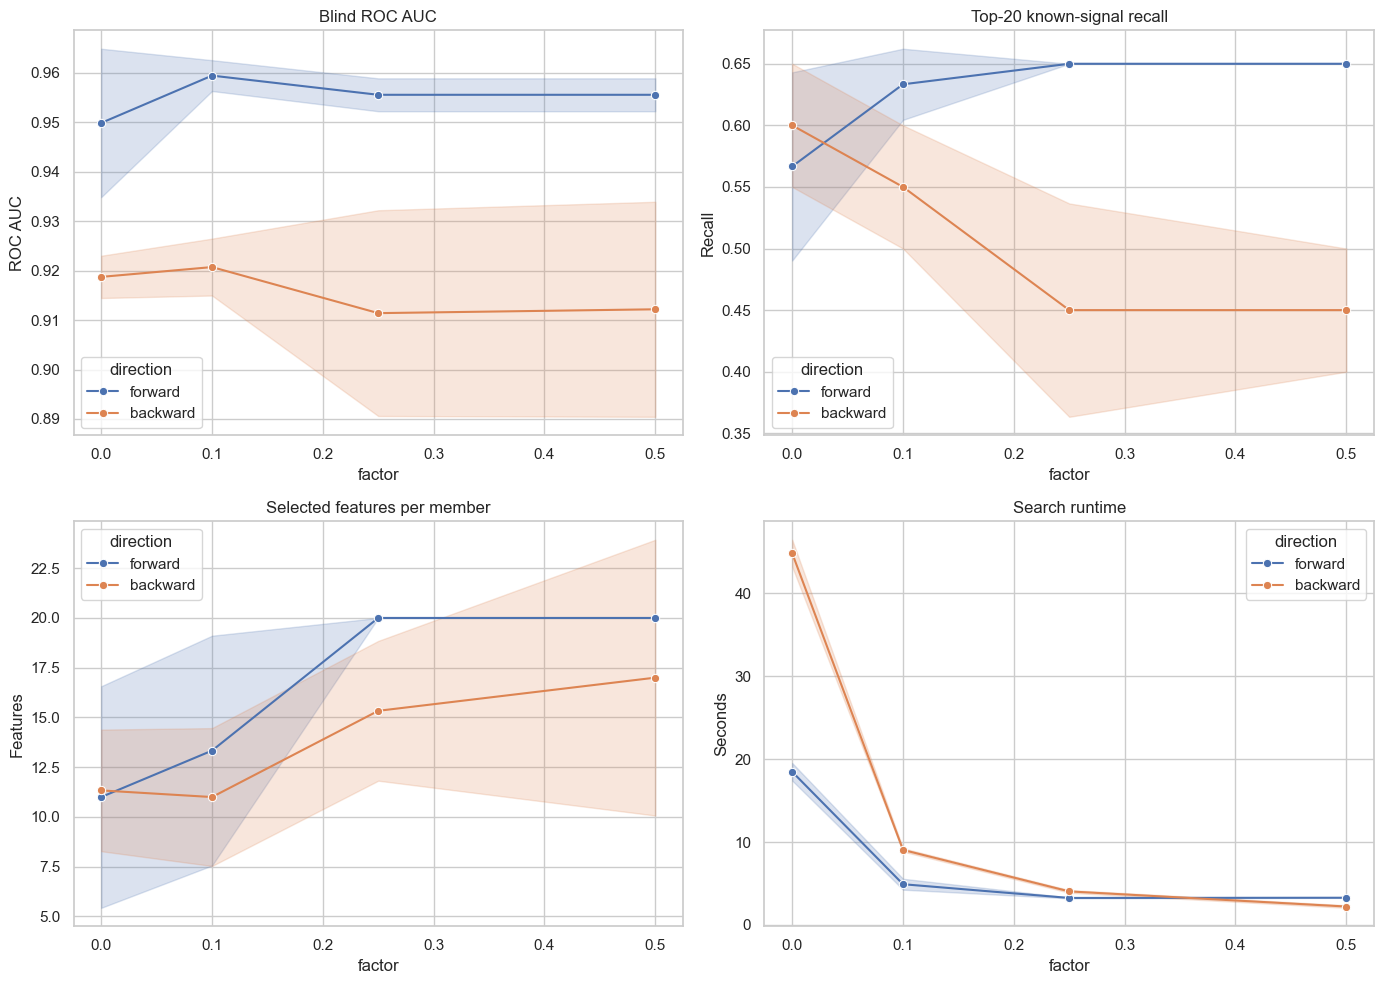

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.lineplot(
    data=factor_results, x="factor", y="roc_auc", hue="direction",
    marker="o", errorbar="sd", ax=axes[0, 0],
)
axes[0, 0].set(title="Blind ROC AUC", ylabel="ROC AUC")

sns.lineplot(
    data=factor_results, x="factor", y="top20_signal_recall",
    hue="direction", marker="o", errorbar="sd", ax=axes[0, 1],
)
axes[0, 1].set(title="Top-20 known-signal recall", ylabel="Recall")

sns.lineplot(
    data=factor_results, x="factor", y="mean_member_features",
    hue="direction", marker="o", errorbar="sd", ax=axes[1, 0],
)
axes[1, 0].set(title="Selected features per member", ylabel="Features")

sns.lineplot(
    data=factor_results, x="factor", y="elapsed_seconds",
    hue="direction", marker="o", errorbar="sd", ax=axes[1, 1],
)
axes[1, 1].set(title="Search runtime", ylabel="Seconds")
plt.tight_layout()

## Feature-performance curve resolution

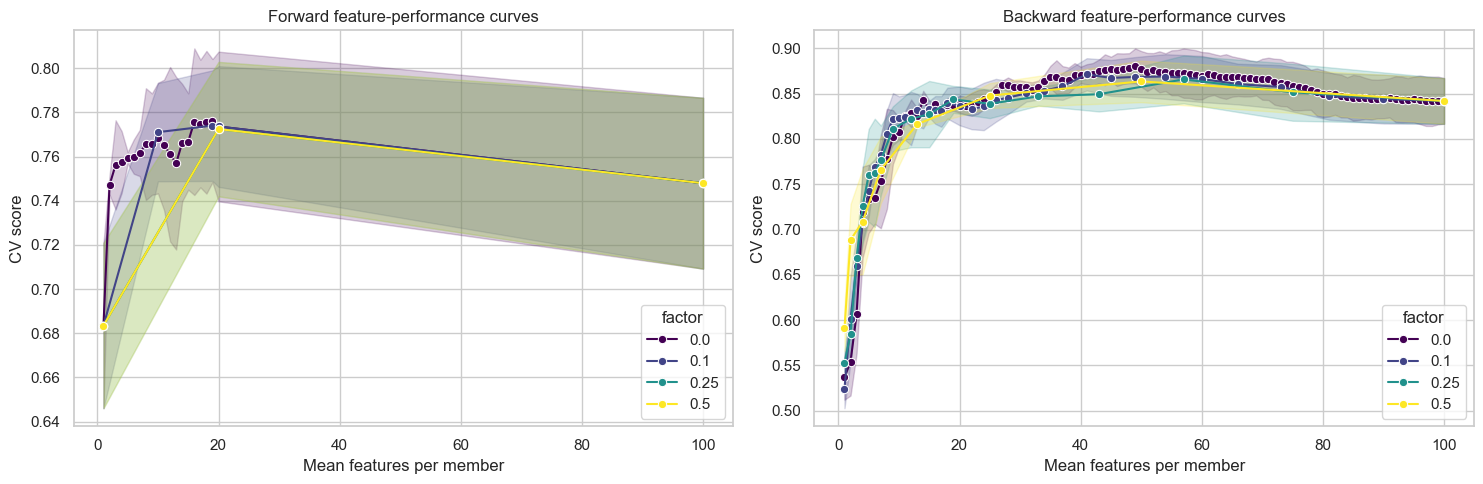

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for axis, direction in zip(axes, DIRECTIONS):
    sns.lineplot(
        data=factor_curves.query("direction == @direction"),
        x="num_features", y="cv_score", hue="factor",
        errorbar="sd", marker="o", ax=axis, palette="viridis",
    )
    axis.set(
        title=f"{direction.title()} feature-performance curves",
        xlabel="Mean features per member", ylabel="CV score",
    )
plt.tight_layout()